# Baseline
Ansatz:
- Übersicht der Multi-view Pig Posture Recognition Challenge
- Datenanalyse und -vorverarbeitung
- Baseline Modellierung für zukunfitge Optimierungen

In [1]:
import os
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from PIL import Image
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from tqdm import tqdm
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split

device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

<jemalloc>: Unsupported system page size


Using device: cuda:3


## Datenanalyse

In [2]:
data_dir = "/datasets/multi-view-pig-posture-recognition/"
train2_df = pd.read_csv(os.path.join(data_dir, "train2.csv"))
dir_train2 = os.path.join(data_dir, "train2_images")

test_df = pd.read_csv(os.path.join(data_dir, "test.csv"))
dir_test = os.path.join(data_dir, "test_images")

print(f"Train2: {len(train2_df)} samples")
print(train2_df.head())
print(f"\nKlassenverteilung:")
print(train2_df["class_id"].value_counts().sort_index())

Train2: 23450 samples
                                     row_id  \
0  train_pen1_orb_cam1_20250108_085204_0000   
1  train_pen1_orb_cam1_20250108_085204_0001   
2  train_pen1_orb_cam1_20250108_085204_0002   
3  train_pen1_orb_cam1_20250108_085204_0003   
4  train_pen1_orb_cam1_20250108_085204_0004   

                            image_id  width  height  \
0  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
1  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
2  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
3  pen1_orb_cam1_20250108_085204.jpg   1920    1080   
4  pen1_orb_cam1_20250108_085204.jpg   1920    1080   

                         bbox  class_id  
0  [1031.5,368.0,349.0,435.0]         0  
1  [1278.5,428.0,233.0,438.0]         4  
2   [732.0,137.5,342.0,198.0]         1  
3   [830.0,169.0,370.0,263.0]         0  
4   [611.5,314.8,381.5,386.6]         3  

Klassenverteilung:
class_id
0    3083
1    3435
2     695
3    9928
4    6309
Name: count, dtype: int64


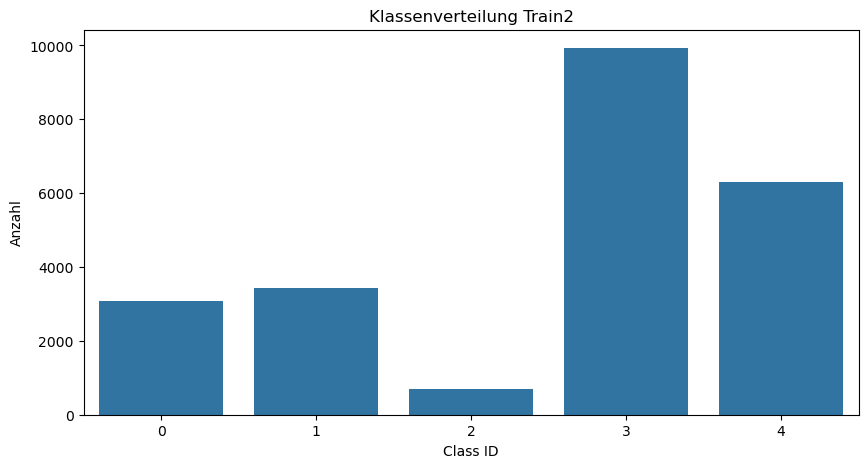

In [3]:
def parse_bbox_safe(x):
    if isinstance(x, str):
        return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x

train2_df["bbox"] = train2_df["bbox"].apply(parse_bbox_safe)

# Klassenverteilung
class_counts = train2_df["class_id"].value_counts().sort_index()
plt.figure(figsize=(10, 5))
sns.barplot(x=class_counts.index, y=class_counts.values)
plt.title("Klassenverteilung Train2")
plt.xlabel("Class ID")
plt.ylabel("Anzahl")
plt.show()

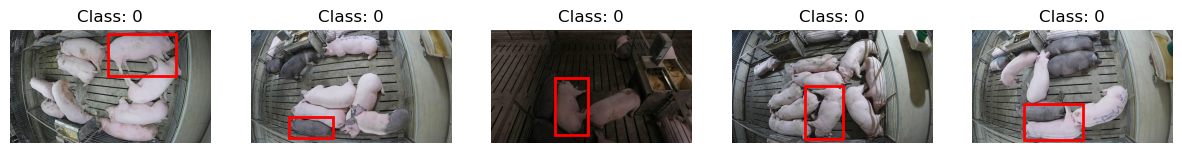

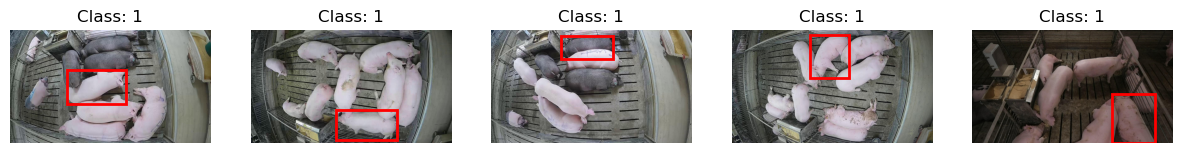

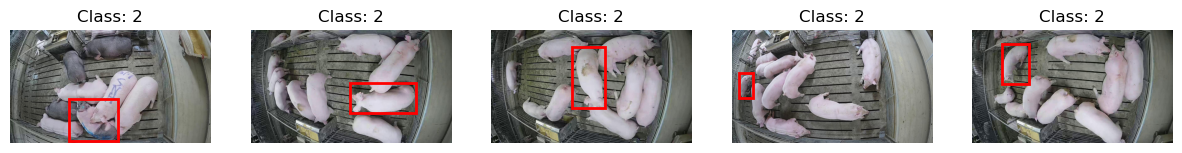

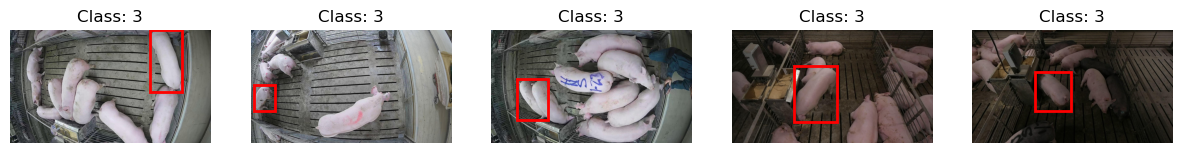

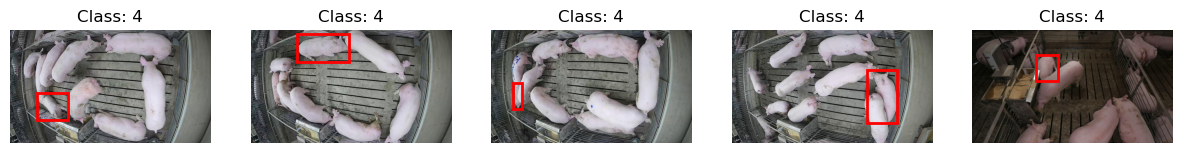

In [4]:
def show_grid_per_class(df, img_dir, class_id, num_images=5):
    subset = df[df["class_id"] == class_id].sample(n=num_images, replace=True)
    plt.figure(figsize=(15, 3))
    for i, (_, row) in enumerate(subset.iterrows()):
        img_path = os.path.join(img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        bbox = row["bbox"]
        
        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.axis("off")
        plt.title(f"Class: {class_id}")
    plt.show()

for c in sorted(train2_df["class_id"].unique()):
    show_grid_per_class(train2_df, dir_train2, c)

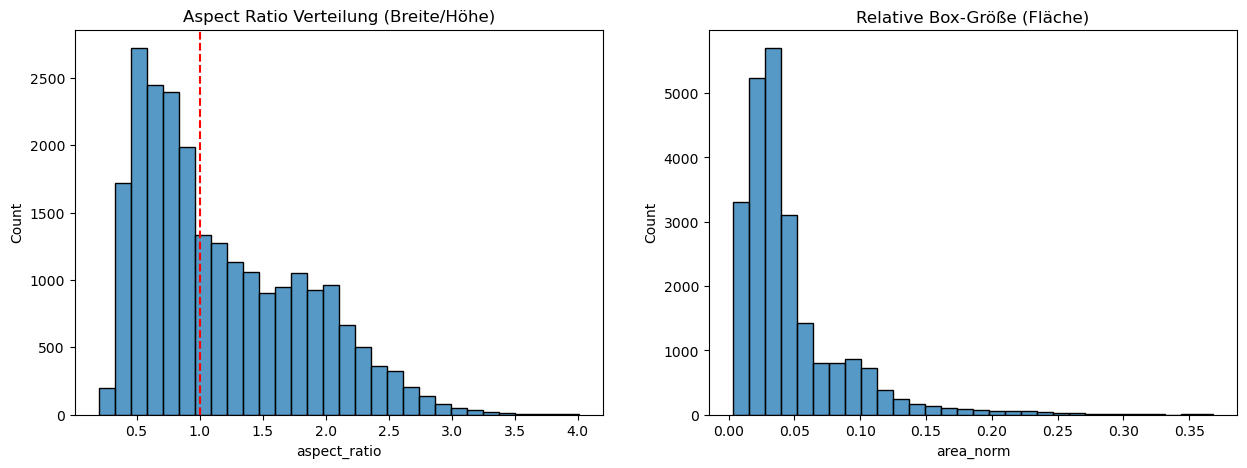

In [9]:
train2_df["bbox"] = train2_df["bbox"].apply(parse_bbox_safe)

bbox_data = train2_df["bbox"].tolist()
bbox_stats = pd.DataFrame(bbox_data, columns=["x", "y", "w", "h"])

bbox_stats["aspect_ratio"] = bbox_stats["w"] / bbox_stats["h"]
bbox_stats["area_norm"] = (bbox_stats["w"] * bbox_stats["h"]) / (1920 * 1080)

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.histplot(bbox_stats["aspect_ratio"], bins=30, ax=ax[0])
ax[0].set_title("Aspect Ratio Verteilung (Breite/Höhe)")
ax[0].axvline(1, color="red", linestyle="--")

sns.histplot(bbox_stats["area_norm"], bins=30, ax=ax[1])
ax[1].set_title("Relative Box-Größe (Fläche)")
plt.show()

In [10]:
class PigPostureDataset(Dataset):
    def __init__(self, df, img_dir, transform=None):
        self.df = df.reset_index(drop=True)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        label = row["class_id"]

        bbox = row["bbox"]
        if isinstance(bbox, str):
            bbox = [float(x) for x in bbox.replace("[", "").replace("]", "").split(",")]
        x, y, w, h = bbox
        img_w, img_h = image.size
        x1 = max(0, int(x))
        y1 = max(0, int(y))
        x2 = min(img_w, int(x + w))
        y2 = min(img_h, int(y + h))
        image = image.crop((x1, y1, x2, y2))

        if self.transform:
            image = self.transform(image)

        return image, label

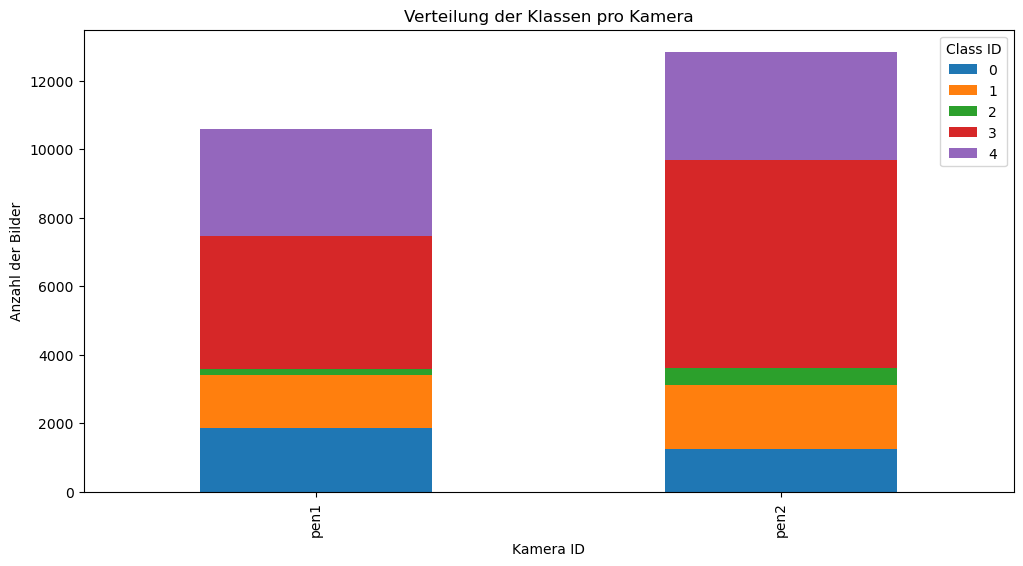

In [12]:
train2_df["camera_id"] = train2_df["image_id"].apply(lambda x: x.split("_")[0])
camera_class_counts = (
    train2_df.groupby(["camera_id", "class_id"]).size().unstack(fill_value=0)
)
plt.figure(figsize=(12, 6))
camera_class_counts.plot(kind="bar", stacked=True, ax=plt.gca())
plt.title("Verteilung der Klassen pro Kamera")
plt.xlabel("Kamera ID")
plt.ylabel("Anzahl der Bilder")
plt.legend(title="Class ID")
plt.show()

# Model


In [13]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1, hue=0.05),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

transform_val = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_split_df, val_split_df = train_test_split(
    train2_df, test_size=0.2, random_state=42, stratify=train2_df["class_id"]
)

print(f"Train: {len(train_split_df)} samples")
print(f"Val:   {len(val_split_df)} samples")

train_dataset = PigPostureDataset(train_split_df, dir_train2, transform=transform_train)
val_dataset = PigPostureDataset(val_split_df, dir_train2, transform=transform_val)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=4, pin_memory=True)

Train: 18760 samples
Val:   4690 samples


In [15]:
class PigPostureModel(nn.Module):
    def __init__(self, num_classes=5):
        super(PigPostureModel, self).__init__()
        self.backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

        for param in self.backbone.parameters():
            param.requires_grad = False

        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def unfreeze_last_layers(self, num_layers=2):
        layers = [
            self.backbone.layer1,
            self.backbone.layer2,
            self.backbone.layer3,
            self.backbone.layer4,
        ]
        for layer in layers[-num_layers:]:
            for param in layer.parameters():
                param.requires_grad = True
        print(f"Unfroze last {num_layers} backbone layers for fine-tuning.")

    def forward(self, x):
        return self.backbone(x)

model = PigPostureModel(num_classes=5)

In [16]:
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler=None, num_epochs=10, save_name="best_model_T2.pth"):
    model.to(device)
    train_loss_history = []
    val_loss_history = []
    val_acc_history = []
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]"):
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)

        epoch_train_loss = running_loss / len(train_loader.dataset)
        train_loss_history.append(epoch_train_loss)

        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]"):
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = correct / total
        val_loss_history.append(epoch_val_loss)
        val_acc_history.append(epoch_val_acc)

        if scheduler:
            scheduler.step(epoch_val_loss)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f} | "
              f"Val Acc: {epoch_val_acc:.4f}")

        if epoch_val_acc > best_val_acc:
            best_val_acc = epoch_val_acc
            torch.save(model.state_dict(), save_name)
            print(f"  -> Neues bestes Modell gespeichert! (Val Acc: {best_val_acc:.4f})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(range(1, num_epochs + 1), train_loss_history, marker="o", label="Train Loss")
    axes[0].plot(range(1, num_epochs + 1), val_loss_history, marker="s", label="Val Loss")
    axes[0].set_title("Loss über Epochen")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid()

    axes[1].plot(range(1, num_epochs + 1), val_acc_history, marker="o", color="green")
    axes[1].set_title("Validation Accuracy über Epochen")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].grid()

    plt.tight_layout()
    plt.show()
    print(f"\nBeste Validation Accuracy: {best_val_acc:.4f}")

=== Phase 1: Training Classifier Head (T2) ===


Epoch 1/10 [Val]: 100%|██████████| 147/147 [00:26<00:00,  5.64it/s]


Epoch 1/10 | Train Loss: 0.8980 | Val Loss: 0.7183 | Val Acc: 0.7350
  -> Neues bestes Modell gespeichert! (Val Acc: 0.7350)


Epoch 2/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.71it/s]


Epoch 2/10 | Train Loss: 0.7407 | Val Loss: 0.6421 | Val Acc: 0.7586
  -> Neues bestes Modell gespeichert! (Val Acc: 0.7586)


...

Epoch 8/10 | Train Loss: 0.5744 | Val Loss: 0.5021 | Val Acc: 0.8209
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8209)


Epoch 9/10 [Val]: 100%|██████████| 147/147 [00:26<00:00,  5.55it/s]


Epoch 9/10 | Train Loss: 0.5562 | Val Loss: 0.5037 | Val Acc: 0.8164


Epoch 10/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.70it/s]


Epoch 10/10 | Train Loss: 0.5537 | Val Loss: 0.4984 | Val Acc: 0.8151


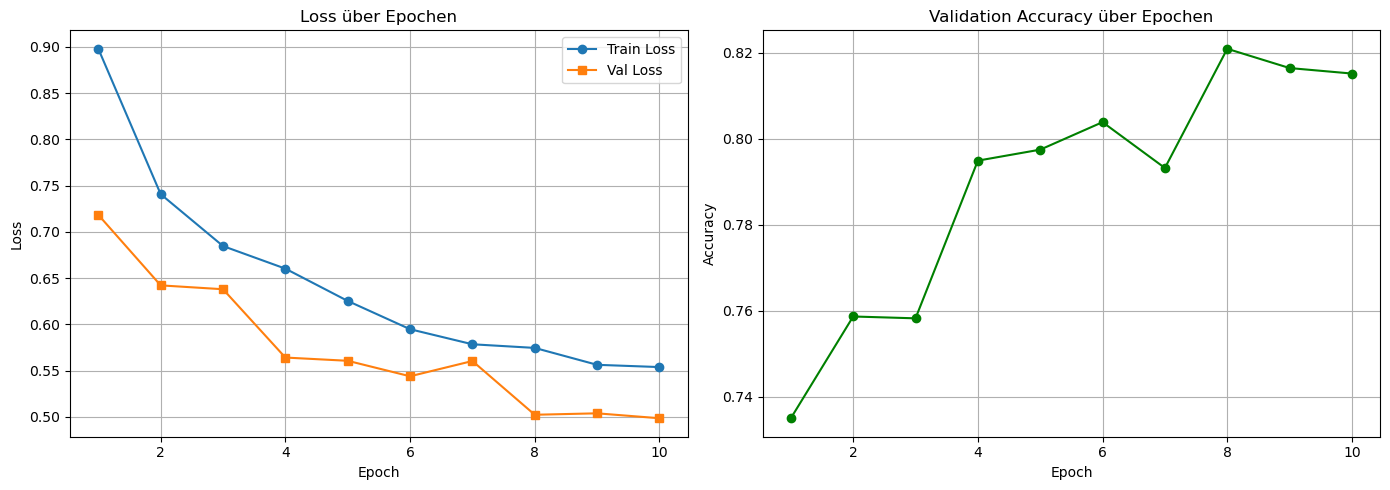


Beste Validation Accuracy: 0.8209


In [17]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.backbone.fc.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=3, factor=0.5)

print("=== Phase 1: Training Classifier Head (T2) ===")
train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, num_epochs=10, save_name="best_model_T2.pth")

Unfroze last 2 backbone layers for fine-tuning.
=== Phase 2: Fine-Tuning Last Backbone Layers (T2) ===


Epoch 1/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.68it/s]


Epoch 1/10 | Train Loss: 0.4707 | Val Loss: 0.4215 | Val Acc: 0.8467
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8467)


Epoch 2/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.71it/s]


Epoch 2/10 | Train Loss: 0.4197 | Val Loss: 0.3859 | Val Acc: 0.8623
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8623)


...

Epoch 8/10 | Train Loss: 0.2629 | Val Loss: 0.2893 | Val Acc: 0.8966
  -> Neues bestes Modell gespeichert! (Val Acc: 0.8966)


Epoch 9/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.68it/s]


Epoch 9/10 | Train Loss: 0.2549 | Val Loss: 0.2795 | Val Acc: 0.9019
  -> Neues bestes Modell gespeichert! (Val Acc: 0.9019)


Epoch 10/10 [Val]: 100%|██████████| 147/147 [00:25<00:00,  5.70it/s]


Epoch 10/10 | Train Loss: 0.2353 | Val Loss: 0.2705 | Val Acc: 0.9053
  -> Neues bestes Modell gespeichert! (Val Acc: 0.9053)


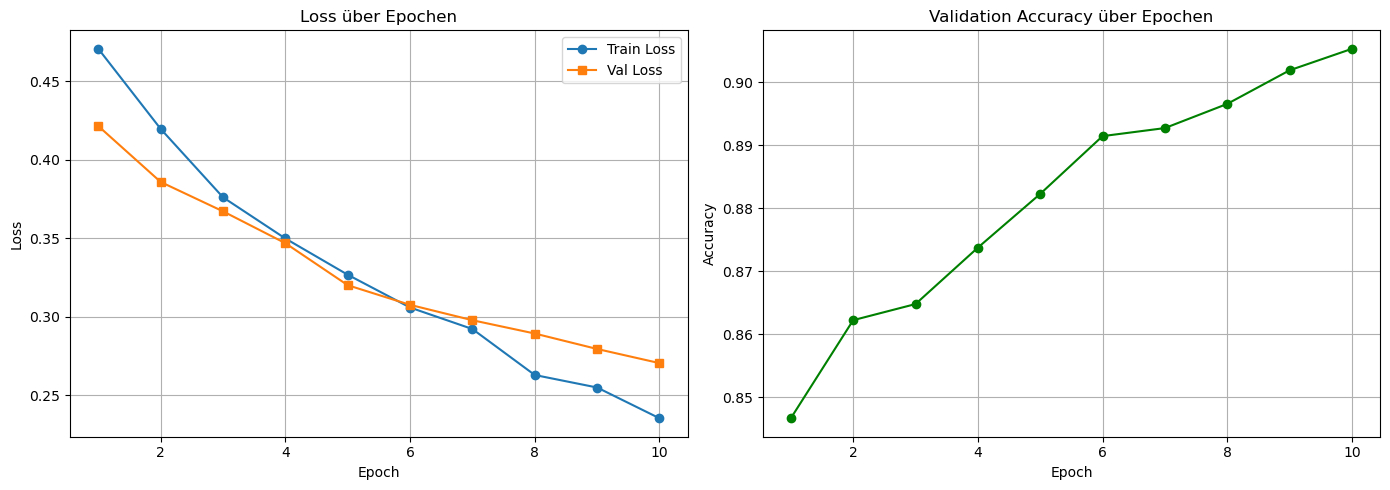


Beste Validation Accuracy: 0.9053


In [18]:
model.unfreeze_last_layers(num_layers=2)

optimizer_ft = torch.optim.Adam([
    {"params": model.backbone.layer3.parameters(), "lr": 1e-5},
    {"params": model.backbone.layer4.parameters(), "lr": 1e-5},
    {"params": model.backbone.fc.parameters(), "lr": 1e-4},
])
scheduler_ft = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_ft, mode="min", patience=3, factor=0.5)

print("=== Phase 2: Fine-Tuning Last Backbone Layers (T2) ===")
train_model(model, train_loader, val_loader, criterion, optimizer_ft, scheduler_ft, num_epochs=10, save_name="best_model_T2.pth")

=== Evaluation auf Validation Set (T2) ===


Evaluating: 100%|██████████| 147/147 [00:25<00:00,  5.70it/s]



Accuracy: 0.9053


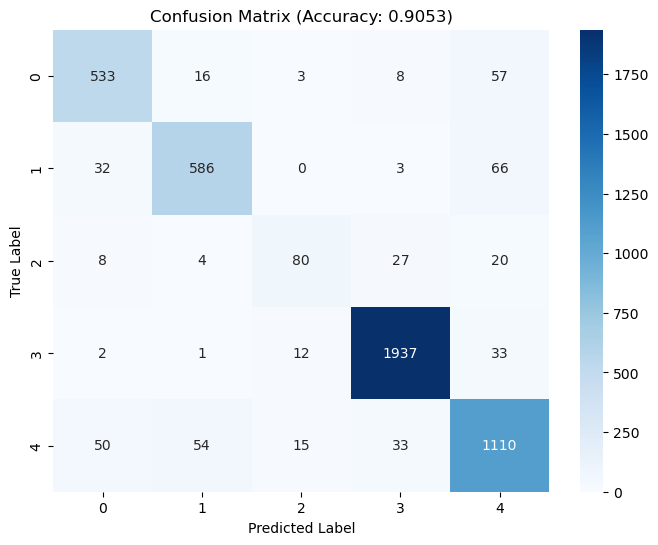

0.9053304904051173

In [19]:
model.load_state_dict(torch.load("best_model_T2.pth"))

def evaluate_model(model, dataloader):
    model.to(device)
    model.eval()
    correct = 0
    total = 0
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in tqdm(dataloader, desc="Evaluating"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    accuracy = correct / total
    print(f"\nAccuracy: {accuracy:.4f}")

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=range(5), yticklabels=range(5))
    plt.title(f"Confusion Matrix (Accuracy: {accuracy:.4f})")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    return accuracy

print("=== Evaluation auf Validation Set (T2) ===")
evaluate_model(model, val_loader)

In [20]:
# Zelle 12: Inference auf Test-Daten
model.load_state_dict(torch.load("best_model_T2.pth", map_location=device))
model.to(device)
model.eval()

row_ids = []
predictions = []

with torch.no_grad():
    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Inference"):
        row_id = row["row_id"]
        image_id = row["image_id"]

        img_path = os.path.join(dir_test, image_id)
        image = Image.open(img_path).convert("RGB")

        bbox = json.loads(row["bbox"])
        x, y, w, h = bbox
        image = image.crop((x, y, x + w, y + h))

        image = transform_val(image).unsqueeze(0).to(device)

        output = model(image)
        _, pred = torch.max(output, 1)

        row_ids.append(row_id)
        predictions.append(pred.item())

submission = pd.DataFrame({
    "row_id": row_ids,
    "class_id": predictions
})

submission.to_csv("T2_resnet_finetune.csv", index=False)

print("\n✅ Gespeichert als: T2_resnet_finetune.csv")
print(f"\nKlassenverteilung:")
print(submission["class_id"].value_counts().sort_index().to_string())
print(submission.head())

Inference: 100%|██████████| 11708/11708 [05:33<00:00, 35.12it/s]



✅ Gespeichert als: T2_resnet_finetune.csv

Klassenverteilung:
class_id
0    1621
1     410
2     832
3    5166
4    3679
                                    row_id  class_id
0  test_pen1_tur_cam1_20250920_174649_0000         3
1  test_pen1_tur_cam1_20250920_174649_0001         1
2  test_pen1_tur_cam1_20250920_174649_0002         0
3  test_pen1_tur_cam1_20250920_174649_0003         3
4  test_pen1_tur_cam1_20250920_174649_0004         0


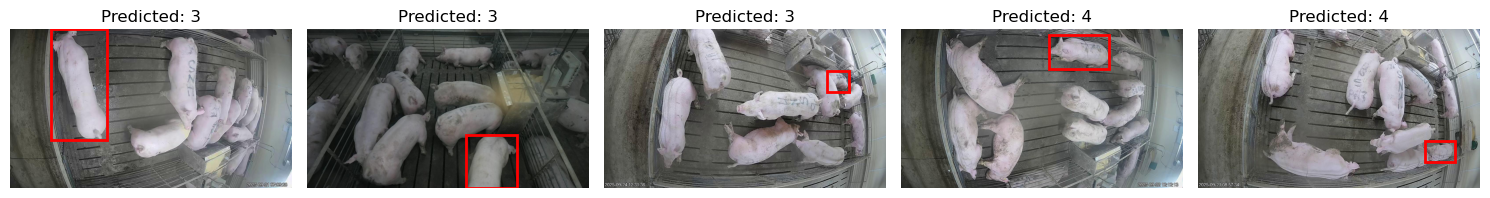

In [21]:
submission_full = submission.merge(test_df[["row_id", "image_id", "bbox"]], on="row_id")

def show_predicted_images(df, img_dir, num_images=5):
    samples = df.sample(n=num_images).reset_index(drop=True)
    plt.figure(figsize=(15, 3))
    for i, row in samples.iterrows():
        img_path = os.path.join(img_dir, row["image_id"])
        image = Image.open(img_path).convert("RGB")
        bbox = json.loads(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]

        plt.subplot(1, num_images, i + 1)
        plt.imshow(image)
        x, y, w, h = bbox
        plt.gca().add_patch(
            plt.Rectangle((x, y), w, h, edgecolor="red", facecolor="none", linewidth=2)
        )
        plt.title(f"Predicted: {row['class_id']}")
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_predicted_images(submission_full, dir_test, num_images=5)